# Class 5 – Logistic Regression in Python (Student Notebook)

**Audience:** R users transitioning to Python
**Goal:** Translate logistic regression workflows from R (`glm`, `tidymodels`) to Python

> ✍️ **Instructions:** This notebook contains guided prompts and TODOs. Do **not** skip the reflection questions — they are part of the learning objectives.

---

## 1. Learning Objectives

By the end of this lesson, you should be able to:

* Explain logistic regression using **log-odds** and **odds ratios**
* Translate an R `glm()` logistic regression into Python using **statsmodels**
* Translate a **tidymodels** classification workflow into **scikit-learn**
* Compare inference-focused vs prediction-focused modeling choices
* Evaluate classification models using appropriate metrics

---

## 2. Setup

In [1]:
# TODO: Run this cell
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

## 3. Data and Binary Outcome

In **R**, you might create a binary outcome like this:

```r
df <- df %>%
  mutate(high_price = if_else(price > median(price), 1, 0))
```

### Python Translation

In [33]:
# TODO: Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")


# TODO: Create the binary outcome high_price
df["high_price"] = np.where(df["price"] > np.median(df["price"]), 1, 0)

df.head()



,listing_id,price,size,bedrooms,neighborhood,type,high_price
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0


Median= 201165.0
          listing_id          price         size    bedrooms  high_price
count     600.000000     600.000000   547.000000  576.000000  600.000000
mean   100300.500000  201053.488333  1763.208584    2.244792    0.500000
std       173.349358   34175.725330   701.737347    1.308490    0.500417
min    100001.000000   96746.000000   607.197941    0.000000    0.000000
25%    100150.750000  175044.250000  1285.926707    1.000000    0.000000
50%    100300.500000  201165.000000  1626.257658    2.000000    0.500000
75%    100450.250000  226874.000000  2081.737227    3.000000    1.000000
max    100600.000000  282086.000000  4500.000000    6.000000    1.000000


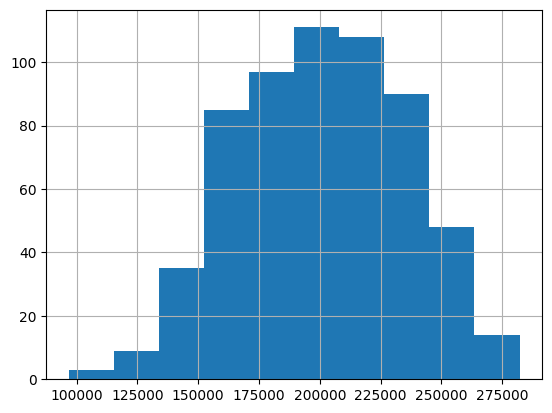

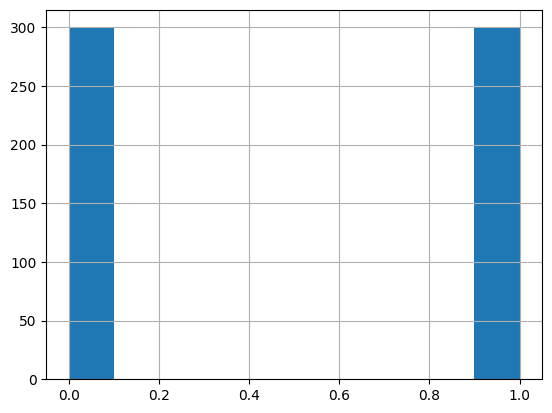

In [13]:
print(f"Median= {np.median(df["price"])}")
print(df.describe())

plt.show(df["price"].hist())
plt.show(df['high_price'].hist())

✏️ **Reflection:** What is the Python equivalent of `if_else()`?

**Answer**  the equivalent of if_else() in Python is np.where()



## 4. Conceptual Warm‑Up: glm vs tidymodels

### In base R (`glm`)

```r
glm(high_price ~ size + neighborhood + type,
    data = df,
    family = binomial)
```

* Single model object
* Inference-first
* No required train/test split

### In tidymodels

```r
log_spec <- logistic_reg() %>%
  set_engine("glm") %>%
  set_mode("classification")

log_fit <- fit(log_spec,
               high_price ~ size + neighborhood + type,
               data = train)
```

* Workflow-first
* Explicit resampling
* Metrics-based evaluation

✏️ **Key idea:** Python separates these workflows into *different libraries*.

---

## 5. Exploratory Analysis

Median price: 201165


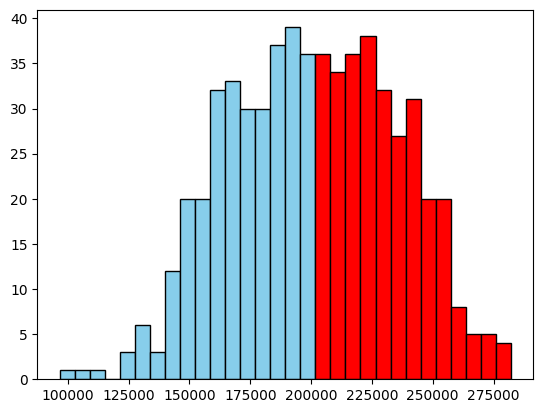

In [18]:
# TODO: Create a histogram of price, colored by high_price

# 1. Calculate the median of the column
median_price = df['price'].median()
print(f"Median price: {median_price:.0f}")

# 2. Plot the histogram and get the bar patches
# N: count in each bin, bins: bin edges, patches: the bar objects
N, bins, patches = plt.hist(df['price'], edgecolor='black', color='grey', bins=30) 

# 4. Iterate over the bars (patches) and color them based on the condition
for patch, bin_center in zip(patches, bins[:-1]):
    # Check if the bin's range (or center) is above the median. 
    if bin_center > median_price:
        patch.set_facecolor('red') # Color bars above median in red
    else:
        patch.set_facecolor('skyblue') # Color bars below median in skyblue


<Axes: xlabel='price', ylabel='Count'>

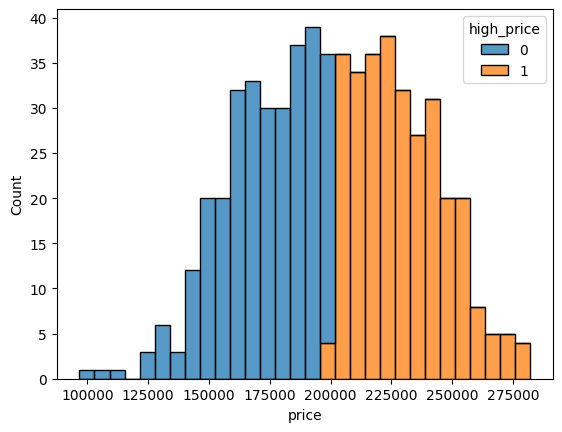

In [ ]:
# in another way, using seaborn, no need to color each bar like with matplotlib

sns.histplot(data=df, x="price", hue="high_price", multiple="stack", bins=30)

✏️ **Reflection:** What would separation look like in this plot?

---

## 6. Logistic Regression with statsmodels (R glm → Python)

### R Reference

```r
model_r <- glm(high_price ~ size + neighborhood + type,
               data = df,
               family = binomial)
summary(model_r)
```

### Python Translation


In [19]:
# TODO: Fit a logistic regression using statsmodels
model_sm = smf.logit(formula="high_price ~ size + neighborhood + type", data=df).fit() 

Optimization terminated successfully.
         Current function value: 0.686263
         Iterations 4


In [20]:
# TODO: Display the model summary
print(model_sm.summary())

                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  547
Model:                          Logit   Df Residuals:                      538
Method:                           MLE   Df Model:                            8
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                0.009929
Time:                        22:53:39   Log-Likelihood:                -375.39
converged:                       True   LL-Null:                       -379.15
Covariance Type:            nonrobust   LLR p-value:                    0.4807
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.1847      0.287      0.644      0.520      -0.378       0.747
neighborhood[T.Midtown]       -0.3162      0.275     -1.148      0.251      -0.856 

✏️ **Reflection:** Identify two similarities between `summary(model_r)` and `model_sm.summary()`.

---

## 7. Odds Ratios

### R

```r
exp(coef(model_r))
```

### Python

In [21]:
# TODO: Compute odds ratios from the statsmodels output
odds_ratios = model_sm.params.apply(np.exp)
odds_ratios

Intercept                     1.202818
neighborhood[T.Midtown]       0.728933
neighborhood[T.Suburb]        1.130512
neighborhood[T.Uptown]        0.994232
neighborhood[T.Waterfront]    1.515414
type[T.MultiFamily]           1.163808
type[T.SingleFamily]          1.144190
type[T.Townhouse]             1.297211
size                          0.999818
dtype: float64


✏️ **Interpretation:** What does an odds ratio greater than 1 mean?

**Answer**  An odds ratio=1 means that the probability of a listing being high_price (=1) is 0.5.    An odds ratio>1 means that the probability of being a high_price home is greater than 0.5 and closer to 1.

## 8. Predicted Probabilities

In [30]:
# TODO: Add predicted probabilities to the DataFrame
df["pred_prob"] = model_sm.predict(df)
df.head()

,listing_id,price,size,bedrooms,neighborhood,type,high_price,pred_prob
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0,0.582896
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0,0.514464
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0,0.426782
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0,0.431537
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0,0.527525


(array([ 5., 10., 20., 23., 33., 19., 26., 38., 42., 75., 70., 70., 45., 43.,
        32., 17., 15.,  7.,  6.,  4.]),
 array([0.35443935, 0.36918351, 0.38392766, 0.39867182, 0.41341597,
        0.42816013, 0.44290428, 0.45764844, 0.47239259, 0.48713674,
        0.5018809 , 0.51662505, 0.53136921, 0.54611336, 0.56085752,
        0.57560167, 0.59034582, 0.60508998, 0.61983413, 0.63457829,
        0.64932244]),
 <BarContainer object of 20 artists>)

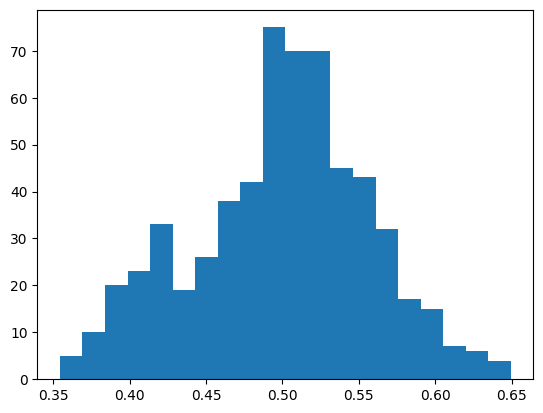

In [31]:
# TODO: Plot the distribution of predicted probabilities
plt.hist(df["pred_prob"], bins=20)

✏️ **Reflection:** Why are probabilities more informative than hard class labels?

-**Answer**   probabilities have a higher resolution than class labels (0 or 1).

## 9. Logistic Regression with scikit‑learn (tidymodels → Python)

### tidymodels analogy

* `initial_split()` → `train_test_split()`
* `fit()` → `.fit()`
* `predict(type = "prob")` → `.predict_proba()`

### Python Workflow


In [ ]:
# drop NaN
df["size"] = df["size"].fillna(df["size"].mean())
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].mean())
df.isna().sum()

# TODO: Create X and y
# Dealing with CATEGORICAL variables# Since "neighborhood" and "type" are categorical, I have to
# replaced them with n dummy variables (n=number of levels - 1).
## A simple way to generate dummy variables is pandas get_dummies. per below.

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=["listing_id", "price","bedrooms", "high_price","pred_prob"])
y = df_encoded["high_price"]

# TODO: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# TODO: Fit a scikit-learn logistic regression model
model_sk = LogisticRegression(max_iter=1000)
model_sk.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
# TODO: Generate class predictions and predicted probabilities
y_pred = model_sk.predict(X_test)
y_prob = model_sk.predict_proba(X_test)[:, 1]

## 10. Model Evaluation


In [38]:
# TODO: Compute accuracy
accuracy_score(y_test, y_pred)

0.43333333333333335

In [39]:
# TODO: Compute confusion matrix
confusion_matrix(y_test, y_pred)

array([[22, 41],
       [27, 30]])

AUC Score: 0.4239766081871345


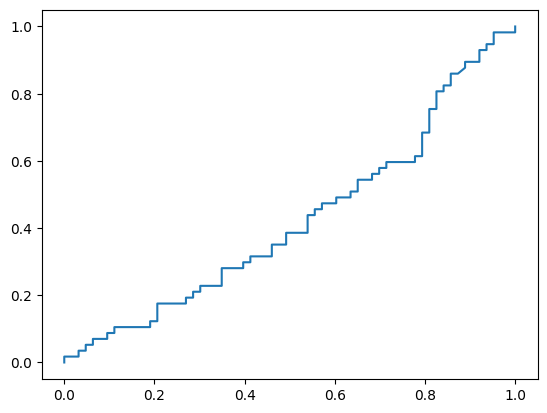

In [ ]:
# TODO: Plot ROC curve and compute AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)

auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc}")

✏️ **Reflection:** Why might AUC be preferred over accuracy?

**Answer** besides the absolute number, the curve gives a visual indication of accuracy. In this case, the ROC being almost diagonal indicates a very poor ability for this model to predict high-price vs not high-price on the basis of the parameters used.

## 11. Comparison Table (Fill In)

| Feature          | R (glm) | R (tidymodels) | statsmodels | scikit‑learn |
| ---------------- | ------- | -------------- | ----------- | ------------ |
| Primary goal     |         |                |             |              |
| Uses formulas    |         |                |             |              |
| Train/test split |         |                |             |              |
| Output           |         |                |             |              |

## 12. Active Learning (15–20 minutes)

**Pair activity:**

1. One student explains logistic regression *using odds*, not probabilities

The logistic regression predicts the log-odds, which yield the odds. A home price with Odds equal to 1 indicate such price can be equally classified as high (1) or not high (0).  Odds greater than 1 indicate that the price can be classified as high, and odds lower than 1 are for prices classified as nont high.


2. The other explains the difference between statsmodels and scikit‑learn

Statsmodels is better suited for explanation and decription of models and statistics of model parameters. Scikit-learn is better suited for prediction and optimization of the model.

3. Together, decide which tool you would use for:

   * Policy analysis --  statsmodels!
   * Price prediction -- scikit-learn!

Be prepared to justify your choices.

## 13. Takeaways

* Logistic regression is the *same model* in R and Python
* Differences are about **workflow and goals**, not mathematics
* statsmodels ≈ `glm`
* scikit‑learn ≈ `tidymodels`
